# Module 15 — Probability, Combinatorics & Bayes (Phase 2: T11, T17 + Naive Bayes)

Probability is the language of uncertainty — the foundation under every statistical
test and ML model. As a Math grad this is home turf; here we make it **computational
and intuitive**, then build up to **Bayes' theorem** and the **Naive Bayes
classifier** (Phase 3, Topic 28) that powers spam filters and your sentiment app.

Goals:
- Counting: permutations vs combinations (and why order matters).
- Probability rules: complement, addition, multiplication, conditional.
- **Independence** vs **mutual exclusivity** (commonly confused).
- **Bayes' theorem** — updating beliefs with evidence (with the classic medical-test
  paradox).
- **Naive Bayes** classifier from scratch *and* with scikit-learn on text.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial, comb, perm
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(0)

## 15.1 Counting — permutations vs combinations

- **Permutation** (order matters): arrangements of r from n = `n! / (n-r)!`.
  *"How many ways to award gold/silver/bronze to 8 runners?"*
- **Combination** (order doesn't matter): selections of r from n =
  `n! / (r!(n-r)!)`. *"How many 5-card poker hands from 52?"*

In [2]:
print("Ways to rank top-3 of 8 runners (order matters):", perm(8, 3))
print("Ways to pick a 3-person committee from 8 (order doesn't):", comb(8, 3))
print("Distinct 5-card poker hands from 52:", comb(52, 5))

# Verify by brute force on a small case
import itertools
items = ["A", "B", "C", "D"]
print("\nperm(4,2) =", perm(4,2), "==", len(list(itertools.permutations(items, 2))))
print("comb(4,2) =", comb(4,2), "==", len(list(itertools.combinations(items, 2))))

Ways to rank top-3 of 8 runners (order matters): 336
Ways to pick a 3-person committee from 8 (order doesn't): 56
Distinct 5-card poker hands from 52: 2598960

perm(4,2) = 12 == 12
comb(4,2) = 6 == 6


## 15.2 Probability rules

- Range: `0 ≤ P(A) ≤ 1`. **Complement**: `P(not A) = 1 − P(A)`.
- **Addition** (either happens): `P(A∪B) = P(A) + P(B) − P(A∩B)`.
- **Multiplication** (both happen): general `P(A∩B) = P(A)·P(B|A)`; if
  **independent**, `= P(A)·P(B)`.
- **Mutually exclusive** ≠ **independent**! Exclusive means they *can't co-occur*
  (`P(A∩B)=0`); independent means one *doesn't affect* the other. These are
  different — a classic interview trap.

In [3]:
# Simulate a fair die to confirm P(even OR >4) via the addition rule
rolls = rng.integers(1, 7, size=200_000)
p_even = np.mean(rolls % 2 == 0)
p_gt4  = np.mean(rolls > 4)
p_both = np.mean((rolls % 2 == 0) & (rolls > 4))     # {6}
p_union_sim = np.mean((rolls % 2 == 0) | (rolls > 4))
p_union_formula = p_even + p_gt4 - p_both
print(f"P(even)={p_even:.3f}  P(>4)={p_gt4:.3f}  P(both)={p_both:.3f}")
print(f"P(even OR >4): simulated={p_union_sim:.3f}, formula={p_union_formula:.3f}")

P(even)=0.497  P(>4)=0.333  P(both)=0.166
P(even OR >4): simulated=0.664, formula=0.664


## 15.3 Conditional probability & Bayes' theorem

**Conditional**: `P(A|B) = P(A∩B) / P(B)` — probability of A *given* B happened.

**Bayes' theorem** flips the condition:

$$ P(H \mid E) = \frac{P(E \mid H)\, P(H)}{P(E)} $$

- `P(H)` = **prior** (belief before evidence).
- `P(E|H)` = **likelihood** (how well H explains the evidence).
- `P(H|E)` = **posterior** (updated belief).
- `P(E)` = evidence (normalizer) = `P(E|H)P(H) + P(E|¬H)P(¬H)`.

This is how you rationally **update beliefs with data** — the core of learning.

### The medical-test paradox (why base rates matter)

A disease affects **1%** of people. A test is **99%** sensitive (`P(+|disease)=0.99`)
and **95%** specific (`P(−|healthy)=0.95`, so false-positive rate 5%). You test
**positive**. What's the chance you actually have the disease? Most people guess
~95%. The truth is shockingly lower — because the disease is rare.

In [4]:
p_disease = 0.01
p_pos_given_disease = 0.99        # sensitivity
p_pos_given_healthy = 0.05        # 1 - specificity

# Bayes
num = p_pos_given_disease * p_disease
den = num + p_pos_given_healthy * (1 - p_disease)
posterior = num / den
print(f"P(disease | positive test) = {posterior:.3f}  (~{posterior*100:.0f}%)")

# Confirm by simulating 1,000,000 people
N = 1_000_000
has = rng.random(N) < p_disease
tests_pos = np.where(has,
                     rng.random(N) < p_pos_given_disease,      # sick: 99% positive
                     rng.random(N) < p_pos_given_healthy)      # healthy: 5% positive
sim = has[tests_pos].mean()
print(f"simulated P(disease | positive) = {sim:.3f}")
print("\nLesson: with a rare disease, most positives are FALSE positives — "
      "base rates dominate. This is 'base-rate neglect'.")

P(disease | positive test) = 0.167  (~17%)
simulated P(disease | positive) = 0.166

Lesson: with a rare disease, most positives are FALSE positives — base rates dominate. This is 'base-rate neglect'.


**Why this matters for DS:** the same logic governs fraud detection, rare-event
churn, and any imbalanced classification. A "99% accurate" test on a 1%-prevalence
problem can still be wrong most of the time it fires — exactly why we obsess over
precision/recall (Module 07), not accuracy.

## 15.4 Naive Bayes classifier — Bayes applied to prediction

For classification, we want `P(class | features)`. By Bayes:

$$ P(y \mid x_1,\dots,x_n) \propto P(y)\prod_i P(x_i \mid y) $$

The **"naive"** assumption: features are **conditionally independent given the
class**. It's usually false, yet works remarkably well — especially for **text**,
where features are word counts. It's fast, needs little data, and is a great
baseline (it likely underpins your Twitter sentiment app).

In [5]:
# Naive Bayes FROM SCRATCH on a tiny spam problem (word presence features)
# Training data: 1 = spam, 0 = ham
docs = [
    ("win money now", 1), ("cheap money offer", 1), ("win free prize", 1),
    ("meeting at noon", 0), ("project deadline today", 0), ("lunch meeting notes", 0),
]
vocab = sorted(set(w for text, _ in docs for w in text.split()))

def word_vector(text):
    words = set(text.split())
    return np.array([1 if w in words else 0 for w in vocab])

X = np.array([word_vector(t) for t, _ in docs])
y = np.array([lab for _, lab in docs])

# Priors
p_spam = y.mean(); p_ham = 1 - p_spam
# Likelihoods P(word|class) with Laplace smoothing (+1) to avoid zero probabilities
def likelihoods(cls):
    subset = X[y == cls]
    return (subset.sum(0) + 1) / (len(subset) + 2)   # +1/+2 = Laplace smoothing

lik_spam, lik_ham = likelihoods(1), likelihoods(0)

def predict(text):
    v = word_vector(text)
    # product of P(word|class) for present words, (1-P) for absent — use logs for stability
    log_spam = np.log(p_spam) + np.sum(np.log(np.where(v==1, lik_spam, 1-lik_spam)))
    log_ham  = np.log(p_ham)  + np.sum(np.log(np.where(v==1, lik_ham,  1-lik_ham)))
    return "SPAM" if log_spam > log_ham else "HAM", log_spam, log_ham

for msg in ["win free money", "project meeting today", "cheap prize now"]:
    label, ls, lh = predict(msg)
    print(f"'{msg}'  -> {label}")

'win free money'  -> SPAM
'project meeting today'  -> HAM
'cheap prize now'  -> SPAM


**Laplace smoothing** (the `+1`) is essential: without it, a word never seen in a
class gets probability 0, which zeroes the entire product. Smoothing keeps unseen
words from vetoing a prediction — a detail interviewers probe.

In [6]:
# The professional version: scikit-learn on the same idea, scaled up
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = [t for t, _ in docs]
labels = [l for _, l in docs]
vec = CountVectorizer()
Xc = vec.fit_transform(texts)
nb_model = MultinomialNB().fit(Xc, labels)

tests = ["win money prize", "deadline meeting notes"]
preds = nb_model.predict(vec.transform(tests))
for t, p in zip(tests, preds):
    print(f"'{t}' -> {'SPAM' if p==1 else 'HAM'}")

'win money prize' -> SPAM
'deadline meeting notes' -> HAM


## 15.5 Common distributions you should name on sight

- **Bernoulli / Binomial** — yes/no trials (coin flips, click/no-click).
- **Poisson** — counts of rare events per interval (support calls per day).
- **Normal (Gaussian)** — the bell curve; sums/means tend toward it (CLT).
- **Uniform** — all outcomes equally likely.
- **Exponential** — waiting time between events; right-skewed.

Knowing which distribution models your variable guides the right test and model.

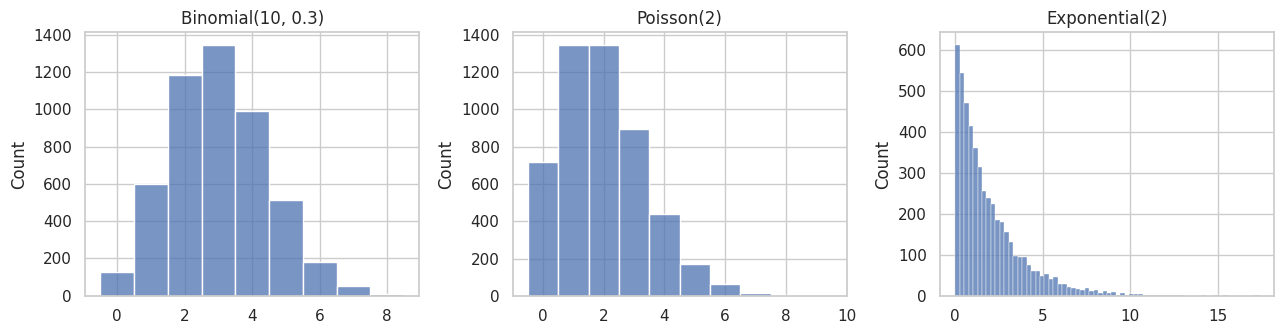

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
sns.histplot(rng.binomial(10, 0.3, 5000), ax=ax[0], discrete=True); ax[0].set_title("Binomial(10, 0.3)")
sns.histplot(rng.poisson(2.0, 5000), ax=ax[1], discrete=True); ax[1].set_title("Poisson(2)")
sns.histplot(rng.exponential(2.0, 5000), ax=ax[2]); ax[2].set_title("Exponential(2)")
plt.tight_layout(); plt.show()

## 15.6 Mini-exercises

1. Compute `P(at least one 6)` in 4 die rolls, via the complement rule; verify by
   simulation.
2. Rework the medical test with disease prevalence **10%**. How does the posterior
   change? Why?
3. Add the word "free" to a ham message in the scratch Naive Bayes — does the
   prediction flip? Explain via the likelihoods.
4. Explain in one sentence why "naive" independence is usually wrong but still
   useful.

## Summary

- **Permutations** (order matters) vs **combinations** (don't); use `math.perm/comb`.
- Probability rules: complement, addition (subtract the overlap), multiplication
  (conditional in general). **Mutually exclusive ≠ independent.**
- **Bayes** updates a **prior** into a **posterior** with a **likelihood**;
  **base rates** dominate (medical-test paradox → same logic as imbalanced ML).
- **Naive Bayes**: `P(y)∏P(xᵢ|y)`, conditional independence, **Laplace smoothing**;
  fast, strong text baseline.
- Recognize Bernoulli/Binomial, Poisson, Normal, Uniform, Exponential on sight.

Next: **Module 16 — A/B Testing, ANOVA & Statistical Power** (proving what *causes*
what).